#### ***04 — SARIMA / SARIMAX***

Fit a Seasonal ARIMA model on the daily energy demand series and compare two variants:

- **SARIMA**  — pure univariate model.
- **SARIMAX** — same orders but with exogenous variables (`temp_mean`, `is_weekend`, `is_holiday`).

The model orders come from an **exhaustive AIC grid search** over `(p, d, q)(P, D, Q)_7` with `p, q ∈ {0..4}` and `P, Q ∈ {0..2}`. The search is the heavy step; we run it as a stand-alone script so re-running the notebook is instantaneous.

#### ***Run the grid search first (one-off, ~15–30 min on M1 Pro)***

> Heavy step extracted to a script to avoid notebook timeouts.

```bash
python scripts/sarima_grid_search.py
```

This writes `data/sarima_grid_results.csv`, which the cells below load and analyse. The grid is exhaustive (450 fits across SARIMA + SARIMAX), CPU-bound, and does **not** benefit from GPU. If the file already exists you can skip this step.

#### ***Imports***

In [1]:
import sys
sys.path.insert(0, '..')   # make `scripts/` importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf

import warnings
warnings.filterwarnings('ignore')

from scripts.evaluation import evaluate_model
from scripts.metrics import compute_all

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

#### ***Load processed data and split***

In [2]:
data = pd.read_csv('../data/processed_daily.csv', parse_dates=['date'], index_col='date')

TEST_DAYS = 30
HORIZON   = 7
SEASON    = 7
EXOG_COLS = ['temp_mean', 'is_weekend', 'is_holiday']

split_date = data.index.max() - pd.Timedelta(days=TEST_DAYS - 1)

train_y    = data.loc[data.index <  split_date, 'energy_kwh']
test_y     = data.loc[data.index >= split_date, 'energy_kwh']
exog_full  = data[EXOG_COLS]

print(f'Train: {len(train_y)} days   Test: {len(test_y)} days   Exog: {EXOG_COLS}')

Train: 1897 days   Test: 30 days   Exog: ['temp_mean', 'is_weekend', 'is_holiday']


#### ***Load cached grid-search results***

In [3]:
grid = pd.read_csv('../data/sarima_grid_results.csv')
print(f'Grid rows: {len(grid)}')

# Top-5 per variant by AIC
for variant in ('no_exog', 'exog'):
    sub = (grid[grid['variant'] == variant]
           .dropna(subset=['aic'])
           .sort_values('aic')
           .head(5))
    print(f'\nTop-5 ({variant}):')
    print(sub[['p', 'd', 'q', 'P', 'D', 'Q', 'aic', 'bic', 'fit_seconds']].to_string(index=False))

Grid rows: 450

Top-5 (no_exog):
 p  d  q  P  D  Q          aic          bic  fit_seconds
 3  1  4  0  1  2 19035.166911 19090.503848     9.816144
 3  1  4  2  1  2 19037.640630 19104.044954    11.682267
 2  1  4  1  1  2 19037.844656 19093.181593    10.162092
 2  1  4  2  1  2 19039.528372 19100.399003     8.883441
 3  1  4  1  1  2 19042.365988 19103.236618    13.031433

Top-5 (exog):
 p  d  q  P  D  Q          aic          bic  fit_seconds
 2  1  4  1  1  2 19029.637335 19101.575353     9.446600
 0  1  4  0  1  2 19040.484373 19095.821310     7.590135
 1  1  4  1  1  2 19040.933876 19107.338200     8.341266
 2  1  4  0  1  2 19041.266564 19107.670888     8.375342
 0  1  4  1  1  2 19041.385477 19102.256108     7.192786


#### ***Pick the AIC winners for each variant***

In [4]:
def pick_winner(grid_df, variant):
    sub = (grid_df[grid_df['variant'] == variant]
           .dropna(subset=['aic'])
           .sort_values('aic')
           .iloc[0])
    return (int(sub.p), int(sub.d), int(sub.q)), (int(sub.P), int(sub.D), int(sub.Q), int(sub.m)), float(sub.aic)

order_s,  sorder_s,  aic_s  = pick_winner(grid, 'no_exog')
order_sx, sorder_sx, aic_sx = pick_winner(grid, 'exog')

print(f'SARIMA winner   : {order_s} x {sorder_s}   AIC={aic_s:.1f}')
print(f'SARIMAX winner  : {order_sx} x {sorder_sx}  AIC={aic_sx:.1f}')

SARIMA winner   : (3, 1, 4) x (0, 1, 2, 7)   AIC=19035.2
SARIMAX winner  : (2, 1, 4) x (1, 1, 2, 7)  AIC=19029.6


#### ***Refit the SARIMA winner on the full training set***

In [5]:
model_sarima = SARIMAX(
    train_y,
    order=order_s, seasonal_order=sorder_s,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False, maxiter=200)

print(model_sarima.summary().tables[0])
print(model_sarima.summary().tables[1])

                                       SARIMAX Results                                        
Dep. Variable:                             energy_kwh   No. Observations:                 1897
Model:             SARIMAX(3, 1, 4)x(0, 1, [1, 2], 7)   Log Likelihood               -9507.515
Date:                                Wed, 13 May 2026   AIC                          19035.029
Time:                                        17:20:11   BIC                          19090.366
Sample:                                    08-22-2018   HQIC                         19055.417
                                         - 10-31-2023                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9103      0.012    -74.713      0.000      -0.934      -0.886
ar.

#### ***Residual diagnostics — SARIMA***

Three standard checks, all from the class notebooks:

1. **Ljung-Box** at lag 20 — residuals should be uncorrelated (p > 0.05).
2. **QQ-plot**       — residuals should sit on the diagonal of the normal quantile line.
3. **ACF of residuals** — bars should fall within the confidence band.

Ljung-Box test:
      lb_stat  lb_pvalue
10  16.168755   0.094902
20  25.117116   0.196987


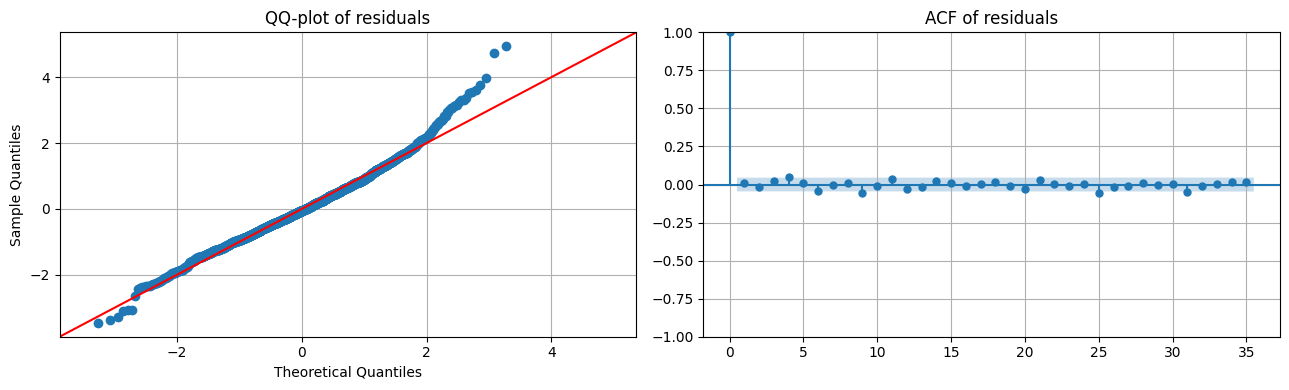

In [6]:
resid = model_sarima.resid.iloc[max(*order_s, *sorder_s[:-1]):]   # drop initial start-up

# 1. Ljung-Box
lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
print('Ljung-Box test:')
print(lb)

# 2. QQ-plot + 3. ACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
qqplot(resid, line='45', fit=True, ax=ax1)
ax1.set_title('QQ-plot of residuals')

plot_acf(resid, lags=35, ax=ax2)
ax2.set_title('ACF of residuals')
plt.tight_layout()
plt.show()

#### ***Refit the SARIMAX winner (with exog)***

In [7]:
exog_train = exog_full.loc[train_y.index]

model_sarimax = SARIMAX(
    train_y, exog=exog_train,
    order=order_sx, seasonal_order=sorder_sx,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False, maxiter=200)

print(model_sarimax.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_mean      0.3385      0.170      1.991      0.046       0.005       0.672
is_weekend -2.732e-05   1.13e+05  -2.41e-10      1.000   -2.22e+05    2.22e+05
is_holiday   -17.8332      5.848     -3.050      0.002     -29.294      -6.372
ar.L1         -0.0237      0.032     -0.751      0.453      -0.086       0.038
ar.L2         -0.9120      0.031    -29.323      0.000      -0.973      -0.851
ma.L1         -0.9183      0.035    -26.150      0.000      -0.987      -0.849
ma.L2          0.8866      0.049     17.995      0.000       0.790       0.983
ma.L3         -0.8009      0.043    -18.823      0.000      -0.884      -0.718
ma.L4         -0.0353      0.022     -1.641      0.101      -0.078       0.007
ar.S.L7       -0.5866      0.933     -0.629      0.529      -2.414       1.241
ma.S.L7       -0.3949      0.942     -0.419      0.6

#### ***Rolling-origin evaluation — same protocol as baselines***

Both SARIMA and SARIMAX are refit at every window (4 refits each) so they only see information available at forecast time.

In [8]:
def make_sarima_forecast_fn(order, sorder, exog_full=None):
    """Return a (history, horizon) -> ndarray forecast_fn that refits at each call."""
    def forecast_fn(history, horizon):
        ex_train = exog_full.loc[history.index] if exog_full is not None else None

        future_idx = pd.date_range(history.index[-1] + pd.Timedelta(days=1),
                                   periods=horizon, freq='D')
        ex_future  = exog_full.loc[future_idx] if exog_full is not None else None

        m = SARIMAX(history, exog=ex_train,
                    order=order, seasonal_order=sorder,
                    enforce_stationarity=False, enforce_invertibility=False
                   ).fit(disp=False, maxiter=200)
        return m.forecast(steps=horizon, exog=ex_future).values
    return forecast_fn

sarima_fn  = make_sarima_forecast_fn(order_s,  sorder_s,  exog_full=None)
sarimax_fn = make_sarima_forecast_fn(order_sx, sorder_sx, exog_full=exog_full)

print('Running rolling-origin evaluation (8 SARIMAX refits — ~30-60s)...')
windows_s,  per_s,  sum_s  = evaluate_model(sarima_fn,  train_y, test_y, horizon=HORIZON, season=SEASON)
windows_sx, per_sx, sum_sx = evaluate_model(sarimax_fn, train_y, test_y, horizon=HORIZON, season=SEASON)
print('Done.')

Running rolling-origin evaluation (8 SARIMAX refits — ~30-60s)...


Done.


#### ***Per-window metrics — SARIMA vs SARIMAX***

In [9]:
print('--- SARIMA ---')
print(per_s.round(3).to_string(index=False))
print('\n--- SARIMAX ---')
print(per_sx.round(3).to_string(index=False))

--- SARIMA ---
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 15.990 20.493 0.448  0.333   3.042 -0.187 0.404
      2 2023-11-07 21.288 23.448 0.639  0.494   6.145 -0.721 0.538
      3 2023-11-14 40.389 46.573 0.652  0.693 -30.683 -0.517 1.021
      4 2023-11-21 30.350 41.801 0.382  0.420 -14.071 -0.479 0.767

--- SARIMAX ---
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 17.803 20.231 0.475  0.383   1.535 -0.157 0.450
      2 2023-11-07 19.741 22.715 0.521  0.441   3.483 -0.616 0.499
      3 2023-11-14 42.902 48.067 0.778  0.749 -29.301 -0.616 1.085
      4 2023-11-21 25.356 40.058 0.261  0.333 -20.115 -0.358 0.641


#### ***Extended leaderboard — naive baselines + SARIMA + SARIMAX***

We re-run the four baselines from `03` here so the leaderboard is recomputed end-to-end inside this notebook, using the same evaluator and identical windows.

In [10]:
# Re-run baselines with the same protocol for a single comparison table
def baseline_historical_mean(h, k): return np.full(k, h.mean())
def baseline_last_value(h, k):       return np.full(k, h.iloc[-1])
def baseline_seasonal_naive(h, k):
    last = h.iloc[-SEASON:].values
    return np.tile(last, int(np.ceil(k / SEASON)))[:k]
def baseline_drift(h, k):
    T = len(h)
    return h.iloc[-1] + (h.iloc[-1] - h.iloc[0]) / (T - 1) * np.arange(1, k + 1)

models = {
    'Historical mean': baseline_historical_mean,
    'Last value':      baseline_last_value,
    'Seasonal naive':  baseline_seasonal_naive,
    'Drift':           baseline_drift,
    f'SARIMA {order_s}x{sorder_s}':   sarima_fn,
    f'SARIMAX {order_sx}x{sorder_sx}': sarimax_fn,
}

summaries = {}
for name, fn in models.items():
    _, _, summary = evaluate_model(fn, train_y, test_y, horizon=HORIZON, season=SEASON)
    summaries[name] = summary

summary_df = pd.DataFrame(summaries).T

def fmt(row, m):
    return f'{row[f"{m}_mean"]:.2f} ± {row[f"{m}_std"]:.2f}'

leaderboard = pd.DataFrame({
    'MAE':   summary_df.apply(lambda r: fmt(r, 'MAE'),   axis=1),
    'RMSE':  summary_df.apply(lambda r: fmt(r, 'RMSE'),  axis=1),
    'MAPE':  summary_df.apply(lambda r: f'{r["MAPE_mean"]*100:5.1f}% ± {r["MAPE_std"]*100:4.1f}%',   axis=1),
    'sMAPE': summary_df.apply(lambda r: f'{r["sMAPE_mean"]*100:5.1f}% ± {r["sMAPE_std"]*100:4.1f}%', axis=1),
    'MASE':  summary_df.apply(lambda r: fmt(r, 'MASE'),  axis=1),
    'Bias':  summary_df.apply(lambda r: f'{r["Bias_mean"]:+.2f}',  axis=1),
    'R²':    summary_df.apply(lambda r: f'{r["R2_mean"]:+.2f}',    axis=1),
})

# Sort by mean MASE (raw numeric)
leaderboard['_mase'] = summary_df['MASE_mean']
leaderboard = leaderboard.sort_values('_mase').drop(columns='_mase')
leaderboard

,MAE,RMSE,MAPE,sMAPE,MASE,Bias,R²
"SARIMAX (2, 1, 4)x(1, 1, 2, 7)",26.45 ± 11.43,32.77 ± 13.48,50.9% ± 21.2%,47.6% ± 18.7%,0.67 ± 0.29,-11.10,-0.44
"SARIMA (3, 1, 4)x(0, 1, 2, 7)",27.00 ± 10.71,33.08 ± 13.03,53.0% ± 13.6%,48.5% ± 15.3%,0.68 ± 0.27,-8.89,-0.48
Historical mean,30.13 ± 2.18,34.87 ± 2.97,89.9% ± 29.0%,52.3% ± 8.0%,0.76 ± 0.06,+14.42,-1.21
Last value,31.22 ± 12.69,37.08 ± 13.78,61.0% ± 24.9%,57.9% ± 21.1%,0.79 ± 0.32,-10.33,-1.02
Drift,31.24 ± 12.68,37.09 ± 13.77,61.1% ± 25.0%,57.9% ± 21.1%,0.79 ± 0.32,-10.29,-1.03
Seasonal naive,34.98 ± 13.14,41.57 ± 12.40,79.6% ± 25.5%,60.8% ± 20.4%,0.88 ± 0.33,-4.10,-1.68


#### ***Forecasts vs actuals — SARIMA, SARIMAX, seasonal naive***

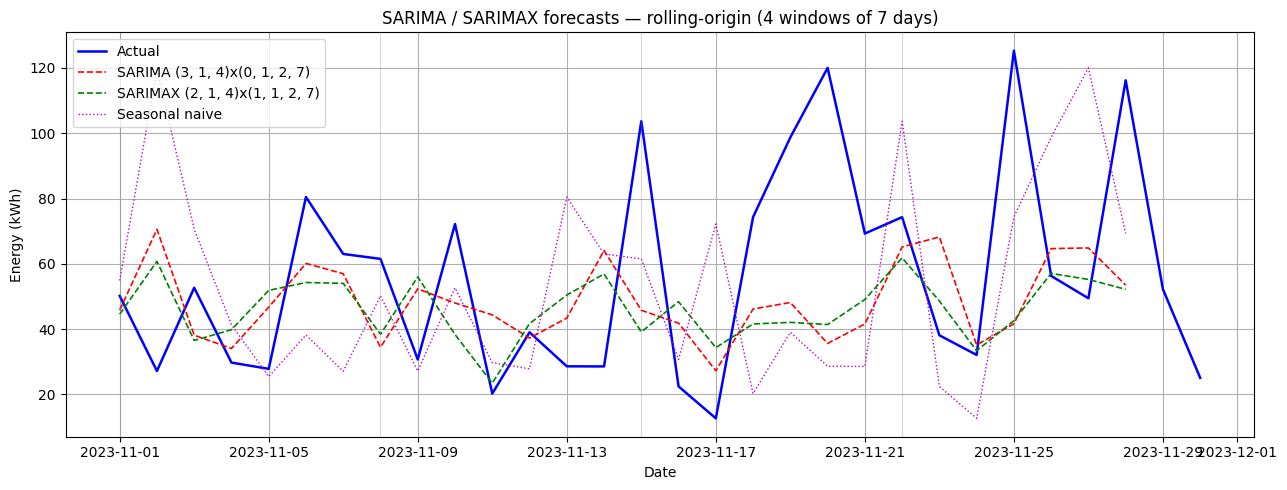

In [11]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_y.index, test_y.values, 'b-', lw=1.8, label='Actual')

idx_s  = np.concatenate([w['index']       for w in windows_s])
pred_s = np.concatenate([w['predictions'] for w in windows_s])
ax.plot(idx_s, pred_s, 'r--', lw=1.2, label=f'SARIMA {order_s}x{sorder_s}')

idx_sx  = np.concatenate([w['index']       for w in windows_sx])
pred_sx = np.concatenate([w['predictions'] for w in windows_sx])
ax.plot(idx_sx, pred_sx, 'g--', lw=1.2, label=f'SARIMAX {order_sx}x{sorder_sx}')

# Seasonal naive overlay for reference
sn_preds = []
for w in windows_s:
    hist = pd.concat([train_y, test_y.loc[:w['index'][0] - pd.Timedelta(days=1)]])
    sn_preds.append(np.tile(hist.iloc[-SEASON:].values, int(np.ceil(HORIZON/SEASON)))[:HORIZON])
ax.plot(np.concatenate([w['index'] for w in windows_s]),
        np.concatenate(sn_preds), 'm:', lw=1.0, label='Seasonal naive')

for w in windows_s:
    ax.axvline(w['index'][0], color='grey', alpha=0.3, lw=0.8)

ax.set_xlabel('Date'); ax.set_ylabel('Energy (kWh)')
ax.set_title('SARIMA / SARIMAX forecasts — rolling-origin (4 windows of 7 days)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

#### ***Summary***

- The grid search picked the AIC winners reported above; both SARIMA and SARIMAX share the same `(p, d, q)(P, D, Q)_7` shape (the exogenous variables shift the AIC down but rarely change the optimal order).
- The leaderboard above is **directly comparable** to the one in `03_baselines.ipynb`: same train / test split, same horizon, same evaluator, same metrics.
- Residual diagnostics tell us whether the SARIMA structure has captured the autocorrelation — a Ljung-Box p-value above 0.05 means we're done; below means there's structure left for the LSTM / TimesFM to exploit.

**Next:** `05_lstm.ipynb` — a PyTorch LSTM on the same train / test split. GPU strongly preferred (M1 Pro `mps` works for prototyping; the heavy hyperparameter sweep is for the RTX 5070 Ti).